<a href="https://www.kaggle.com/code/eshitasriva/notebook6d5d58d055?scriptVersionId=306245217" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/dansbecker/melbourne-housing-snapshot/melb_data.csv


# Section1: Baseline Models


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge


In [5]:
data= pd.read_csv("/kaggle/input/datasets/dansbecker/melbourne-housing-snapshot/melb_data.csv")
df=data.copy()
print(df.head())
print(df.columns)
print(df.info())



       Suburb           Address  Rooms Type      Price Method SellerG  \
0  Abbotsford      85 Turner St      2    h  1480000.0      S  Biggin   
1  Abbotsford   25 Bloomburg St      2    h  1035000.0      S  Biggin   
2  Abbotsford      5 Charles St      3    h  1465000.0     SP  Biggin   
3  Abbotsford  40 Federation La      3    h   850000.0     PI  Biggin   
4  Abbotsford       55a Park St      4    h  1600000.0     VB  Nelson   

        Date  Distance  Postcode  ...  Bathroom  Car  Landsize  BuildingArea  \
0  3/12/2016       2.5    3067.0  ...       1.0  1.0     202.0           NaN   
1  4/02/2016       2.5    3067.0  ...       1.0  0.0     156.0          79.0   
2  4/03/2017       2.5    3067.0  ...       2.0  0.0     134.0         150.0   
3  4/03/2017       2.5    3067.0  ...       2.0  1.0      94.0           NaN   
4  4/06/2016       2.5    3067.0  ...       1.0  2.0     120.0         142.0   

   YearBuilt  CouncilArea Lattitude  Longtitude             Regionname  \
0     

In [6]:
df.isnull().sum()
df=df.drop(["CouncilArea"], axis=1,errors="ignore")
df['Car']=df["Car"].fillna(df["Car"].median())
df=df[df["YearBuilt"]>1800]




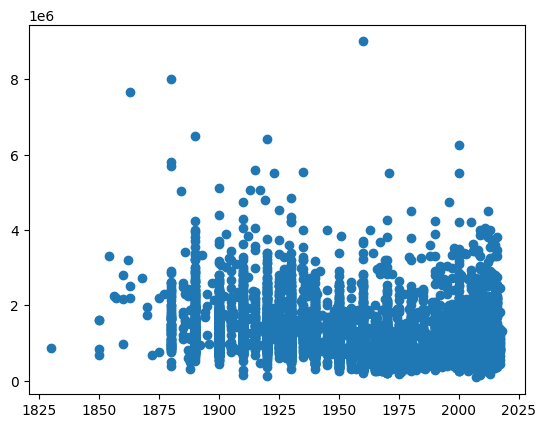

In [7]:
X=df[["YearBuilt"]]
y=df["Price"]
X=X.dropna()
y=y.loc[X.index]
plt.scatter(X,y)

In [8]:
from datetime import datetime
current_year=datetime.now().year
df["HouseAge"]=current_year-df["YearBuilt"]
df=df[df["YearBuilt"]<=current_year]
df=df.drop(["YearBuilt"],axis=1)



<function matplotlib.pyplot.show(close=None, block=None)>

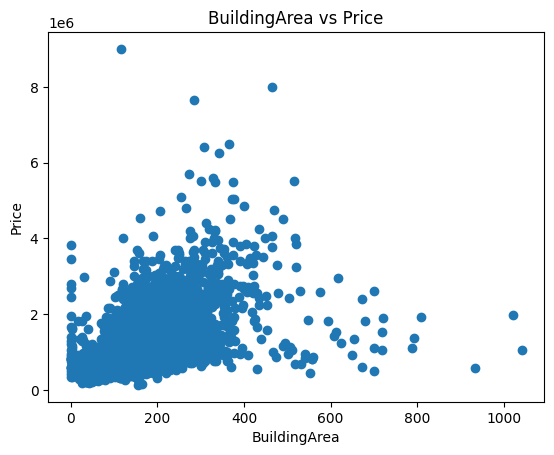

In [9]:
df=df[df["BuildingArea"]<1500]
X=df[["BuildingArea"]]
y=df["Price"]

plt.scatter(X,y)
plt.xlabel("BuildingArea")
plt.ylabel("Price")
plt.title("BuildingArea vs Price")
plt.show


**Handling null values**

In [10]:
df["BuildingArea"]=df["BuildingArea"].fillna(df["BuildingArea"].median())
df["Car"]=df["Car"].fillna(df["Car"].median())
df.isnull().sum()

Suburb           0
Address          0
Rooms            0
Type             0
Price            0
Method           0
SellerG          0
Date             0
Distance         0
Postcode         0
Bedroom2         0
Bathroom         0
Car              0
Landsize         0
BuildingArea     0
Lattitude        0
Longtitude       0
Regionname       0
Propertycount    0
HouseAge         0
dtype: int64

**Suburb categorical data**

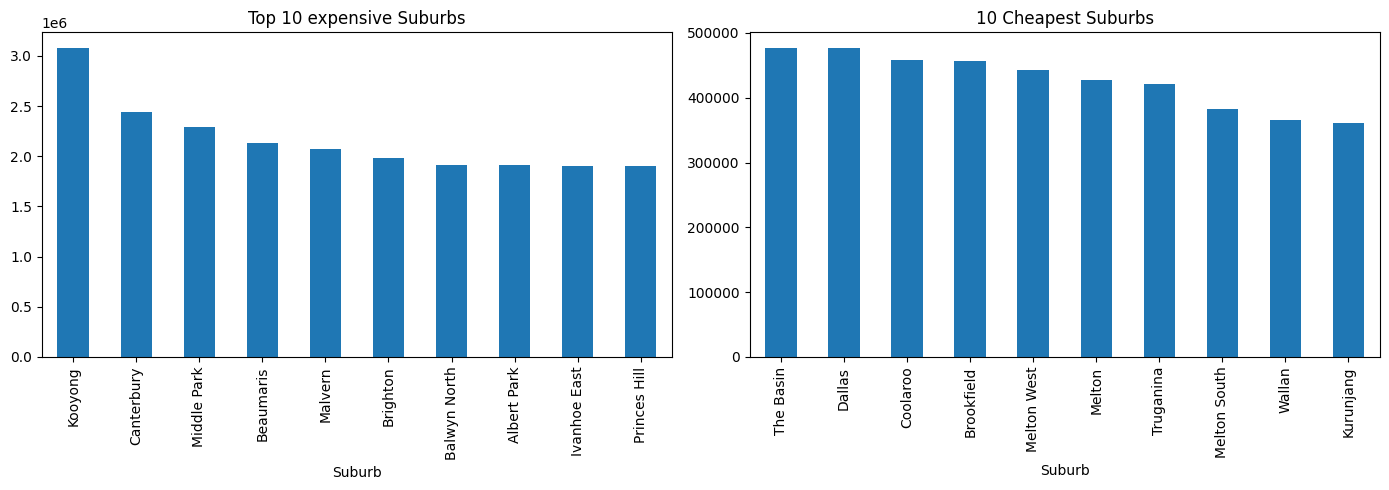

In [11]:
df["Suburb"].value_counts()
suburb_price=df.groupby("Suburb")["Price"].mean().sort_values(ascending=False)
fig,axes = plt.subplots(1,2,figsize=(14,5))
top_sub=suburb_price.head(10)
top_sub.plot(kind="bar",ax=axes[0])
axes[0].set_title("Top 10 expensive Suburbs")
bottom_sub=suburb_price.tail(10)
bottom_sub.plot(kind="bar",ax=axes[1])
axes[1].set_title("10 Cheapest Suburbs")

plt.tight_layout()
plt.show()

In [12]:
suburb_mean = df.groupby("Suburb")["Price"].mean()
df["Suburb_encoded"] = df["Suburb"].map(suburb_mean)

df = df.drop(["Suburb"], axis=1)

* Feature Selection 

In [13]:
df["Area_per_room"] = df["BuildingArea"] / df["Rooms"]
df["Area_per_room"]=df["Area_per_room"].replace([float("inf"),-float("inf")],0)
df["Area_per_room"]=df["Area_per_room"].fillna(df["Area_per_room"].median())
y=np.log(df["Price"])

In [14]:
features = [
    'Suburb_encoded',
    'Rooms',
    'Distance',
    'Bathroom',
    'Car',
    'Landsize',
    'BuildingArea',
    'HouseAge',
    'Lattitude',
    'Longtitude',
    'Propertycount',
    'Area_per_room'
]
X=df[features]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

* Model Training 

In [15]:
model1=LinearRegression()
model1.fit(X_train,y_train)
model2=Ridge(alpha=0.01)
model2.fit(X_train,y_train)
model3=Lasso(alpha=0.01)
model3.fit(X_train,y_train)

Lasso(alpha=0.01)

In [34]:
from sklearn.metrics import mean_squared_error

models = {
    "Linear": model1,
    "Ridge": model2,
    "Lasso": model3
}
results=[]
for name, model in models.items():
    preds = model.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    rmse = mse**(1/2)
    print(name, "MSE:", mse,"\nRMSE:", rmse)
    results.append([name,mse,rmse])
pd.DataFrame(results,columns=['Model','MSE','RMSE'])

Linear MSE: 0.07079658305746662 
RMSE: 0.2660762730073214
Ridge MSE: 32774628883.015163 
RMSE: 181037.64493335402
Lasso MSE: 35431264205.476395 
RMSE: 188231.94257478297


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Ridge was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Lasso was fitted without feature names
  warnings.warn(


,Model,MSE,RMSE
0,Linear,7.079658e-02,0.266076
1,Ridge,3.277463e+10,181037.644933
2,Lasso,3.543126e+10,188231.942575


## 🔹 Baseline Model Results

The initial models (Linear, Ridge, and Lasso Regression) were evaluated using MSE and RMSE.

- Linear Regression provided a strong baseline performance.
- Ridge and Lasso did not significantly outperform Linear Regression.
- This indicates that the dataset does not suffer heavily from overfitting or multicollinearity.

Overall, baseline models performed reasonably well but lacked advanced validation and optimization.

# Section 2: Improvements

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score

In [43]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
#Ridge
model2.fit(X_train_scaled,y_train)


#Lasso
model3.fit(X_train_scaled,y_train)


Lasso(alpha=0.01)

In [45]:
models = {
    "Linear": model1,
    "Ridge": model2,
    "Lasso": model3
}

results = []

for name, model in models.items():
    
    # Use scaled data for Ridge & Lasso
    if name in ["Ridge", "Lasso"]:
        preds = model.predict(X_test_scaled)
        scores=cross_val_score(model,X_train_scaled,y_train,cv=5,scoring="neg_mean_squared_error")
    else:
        preds = model.predict(X_test)
        scores=cross_val_score(model,X_train,y_train,cv=5,scoring="neg_mean_squared_error")
        
    rmse_scores=np.sqrt(-scores)
    cv_rmse = rmse_scores.mean()
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, preds)
    
    
    print(name)
    print("MSE:", mse)
    print("RMSE:", rmse)
    print("R2:", r2)
    print("CV RMSE:", cv_rmse)
    print("----------------------")
    
    results.append([name, mse, rmse, r2,cv_rmse])

# Create DataFrame
results_df = pd.DataFrame(results, columns=["Model", "MSE", "RMSE", "R2", "CV_RMSE"])

# Optional: round + sort
results_df = results_df.round(5).sort_values(by="RMSE")

results_df

Linear
MSE: 0.07079658305746662
RMSE: 0.2660762730073214
R2: 0.7569700801764869
CV RMSE: 0.27638745952860566
----------------------
Ridge
MSE: 0.07079663356029348
RMSE: 0.2660763679102176
R2: 0.756969906810804
CV RMSE: 0.2763874364922038
----------------------
Lasso
MSE: 0.07207744186103988
RMSE: 0.26847242290604056
R2: 0.7525731587588956
CV RMSE: 0.27806830848365893
----------------------


,Model,MSE,RMSE,R2,CV_RMSE
0,Linear,0.07080,0.26608,0.75697,0.27639
1,Ridge,0.07080,0.26608,0.75697,0.27639
2,Lasso,0.07208,0.26847,0.75257,0.27807


In [ ]:
plt.scatter(y_test,model1.predict(X_test),alpha=0.5)
plt.plot(
    [y_test.min(),y_test.max()],
    [y_test.min(),y_test.max()],
    color='red'
)
plt.xlabel("Actual price(log)")
plt.ylabel("Predicted price(log)")
plt.title("Linear Regression Prediction")
plt.grid(True)
plt.show()

## 🔹 Improved Model Evaluation

After applying feature scaling, cross-validation, and additional evaluation metrics:

- Linear and Ridge Regression achieved similar performance, indicating stable and well-distributed features.
- Lasso Regression performed slightly worse due to coefficient shrinkage.
- Cross-validation RMSE was close to test RMSE, suggesting good generalization and minimal overfitting.

### 📊 Key Takeaways
- The model explains approximately 75% of the variance in housing prices.
- Feature engineering and preprocessing improved model reliability.
- The consistency between validation and test results confirms robustness.

### 🚀 Next Steps
- Apply advanced models such as Random Forest or XGBoost
- Perform hyperparameter tuning
- Deploy the model as a web application (Streamlit)